# **ONLINE GAMING BEHAVIOR CLASSIFICATION**

* **Goal**: Predict players' gaming behavior (Win/Lose) using classification models.
* **Dataset**: online_gaming_behavior_dataset.csv (40,035 rows, 13 columns).
* **Models**: Logistic Regression (Baseline) + Random Forest (Advanced).

# *01 - Import Required Libraries*

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# Evaluation Metrics
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import r2_score

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

# *02 - Load Dataset*

In [2]:
#Load the online gaming dataset into a pandas DataFrame.
df = pd.read_csv("/kaggle/input/online-behavior/online_gaming_behavior_dataset.csv")
print(df)

       PlayerID  Age  Gender Location   GameGenre  PlayTimeHours  \
0          9000   43    Male    Other    Strategy      16.271119   
1          9001   29  Female      USA    Strategy       5.525961   
2          9002   22  Female      USA      Sports       8.223755   
3          9003   35    Male      USA      Action       5.265351   
4          9004   33    Male   Europe      Action      15.531945   
...         ...  ...     ...      ...         ...            ...   
40029     49029   32    Male      USA    Strategy      20.619662   
40030     49030   44  Female    Other  Simulation      13.539280   
40031     49031   15  Female      USA         RPG       0.240057   
40032     49032   34    Male      USA      Sports      14.017818   
40033     49033   19    Male      USA      Sports      10.083804   

       InGamePurchases GameDifficulty  SessionsPerWeek  \
0                    0         Medium                6   
1                    0         Medium                5   
2        

# *03 - Dataset shape*

In [3]:
# Check the total number of rows and columns in the dataset.
print("Dataset shape:", df.shape)

Dataset shape: (40034, 13)


# *04 - top order of the data*

In [4]:
# Preview the first few records to understand column names and sample values.
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


# *05 - Data information*

In [5]:
# Display column data types, non-null counts, and overall dataset structure.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

# *06 - data describe*

In [6]:
# Generate summary statistics for numeric and categorical columns.
df.describe()

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


In [7]:
# Helps identify data ranges, outliers, and feature distribution patterns.
df.describe(include=['object'])

,Gender,Location,GameGenre,GameDifficulty,EngagementLevel
count,40034,40034,40034,40034,40034
unique,2,4,5,3,3
top,Male,USA,Sports,Easy,Medium
freq,23959,16000,8048,20015,19374


# ***6.1 - Check for Class Imbalance***

In [8]:
# Check for class imbalance in the target variable
print("Target variable counts (EngagementLevel):")
print(df['EngagementLevel'].value_counts())

Target variable counts (EngagementLevel):
EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64


# *07 - Data Cleaning*

In [9]:
# Drop irrelevant or redundant columns (like ‘InGamePurchases’) to simplify the model.
df = df.drop('InGamePurchases', axis=1)
print("✅ Dropped 'InGamePurchases' column successfully.")

✅ Dropped 'InGamePurchases' column successfully.


# *08 - Exploratory Data Analysis (EDA)*

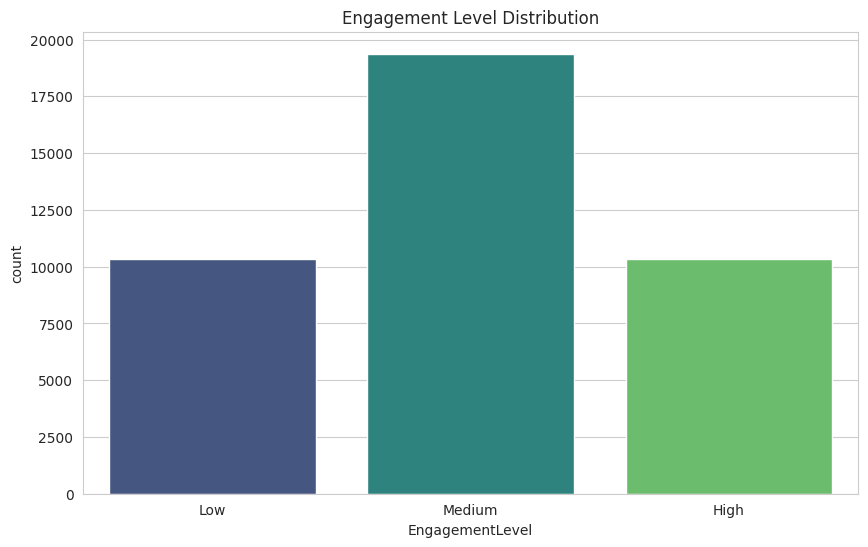

In [10]:
# Visualize overall engagement distribution to understand class balance.
sns.countplot(data=df, x='EngagementLevel', order=['Low', 'Medium', 'High'], palette='viridis')
plt.title('Engagement Level Distribution')
plt.show() # Count Plot

# *8.1 - Pie chart*

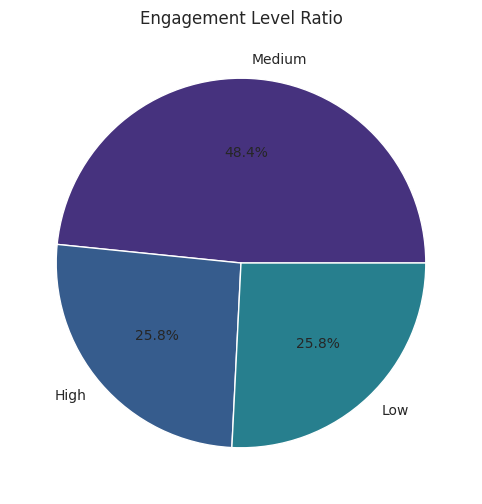

In [11]:
# Show percentage ratio of engagement levels using a pie chart.
engagement_counts = df['EngagementLevel'].value_counts()
plt.pie(engagement_counts, labels=engagement_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis'))
plt.title('Engagement Level Ratio')
plt.show()

# *8.2 - Correlation Heatmap*

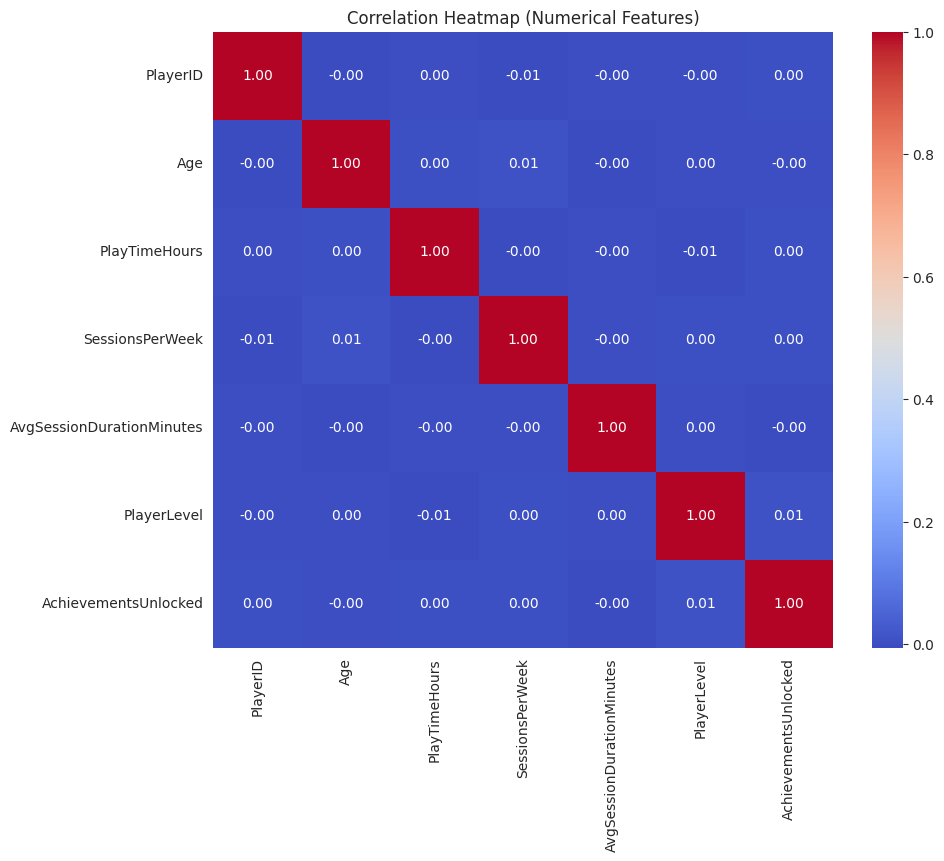

In [12]:
# Plot correlation between numeric features.
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

# *8.3 - Numerical Feature Distributions*

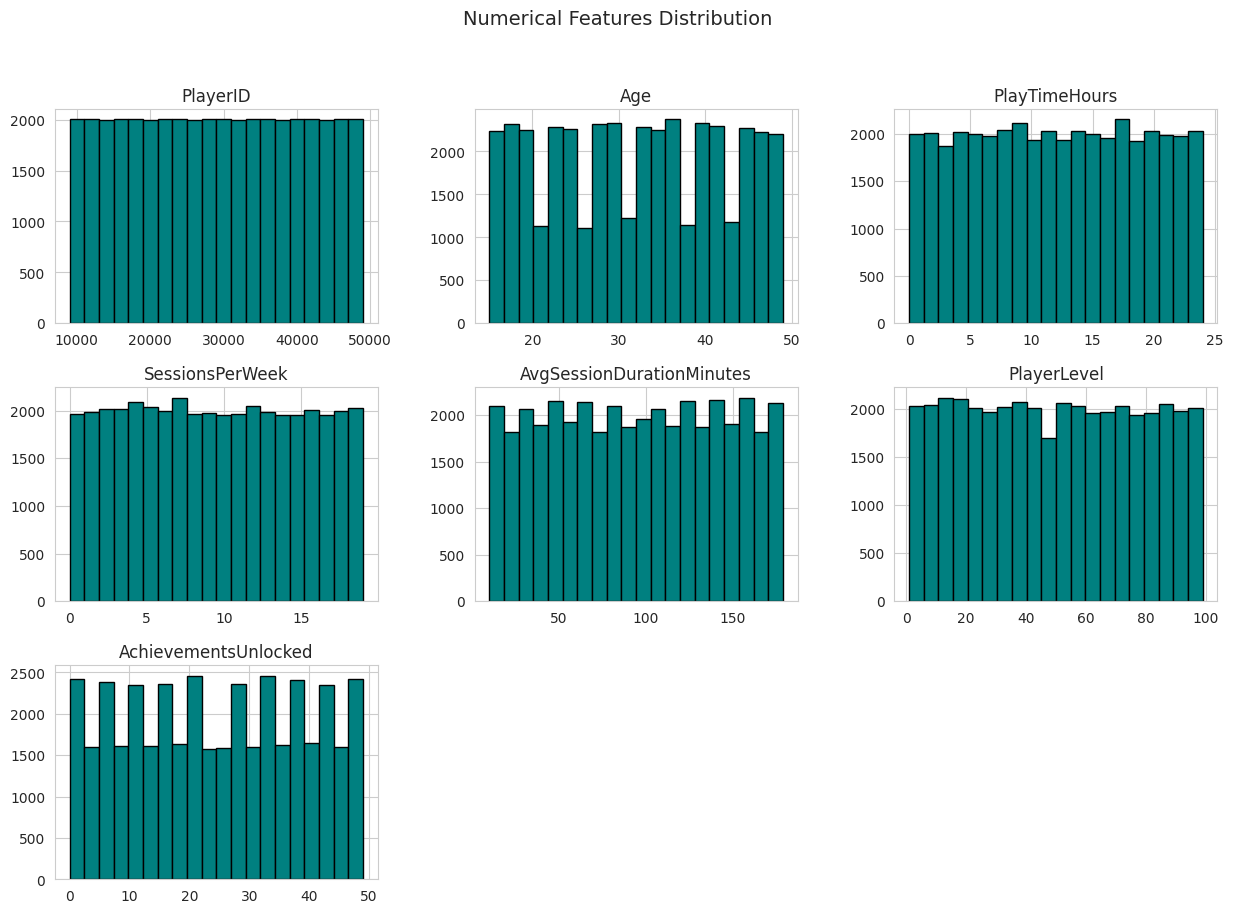

In [13]:
# Visualize histograms of numeric features.
num_features = df.select_dtypes(include=np.number).columns
df[num_features].hist(bins=20, figsize=(15,10), color='teal', edgecolor='black')
plt.suptitle('Numerical Features Distribution', fontsize=14)
plt.show()

# *8.4 - Categorical Features Visualization*

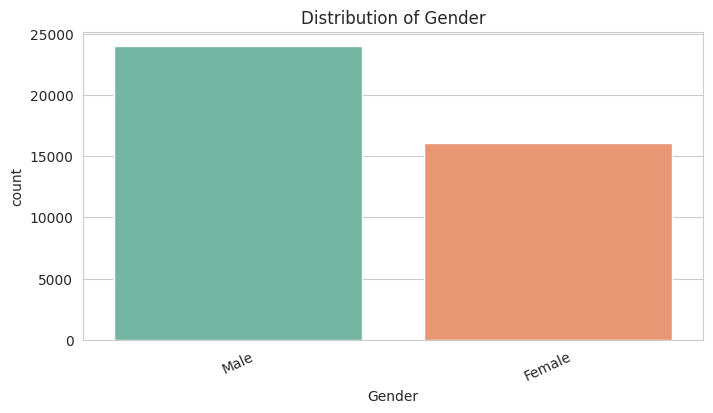

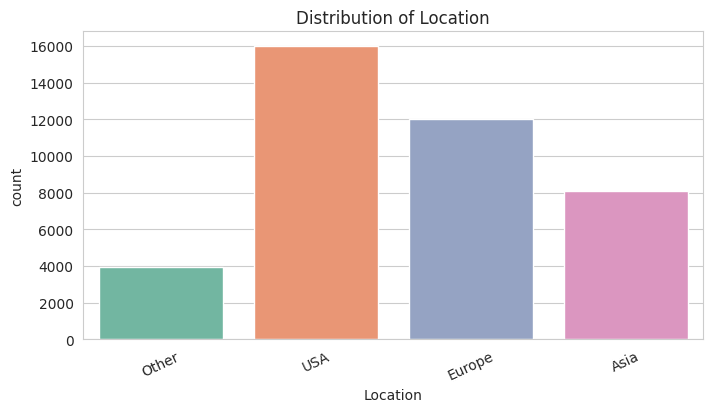

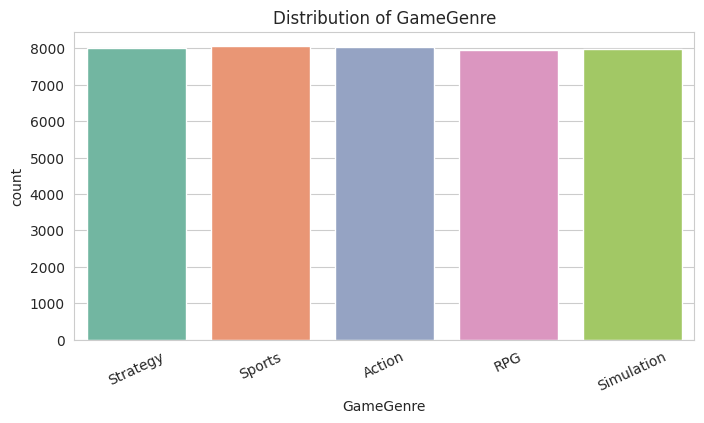

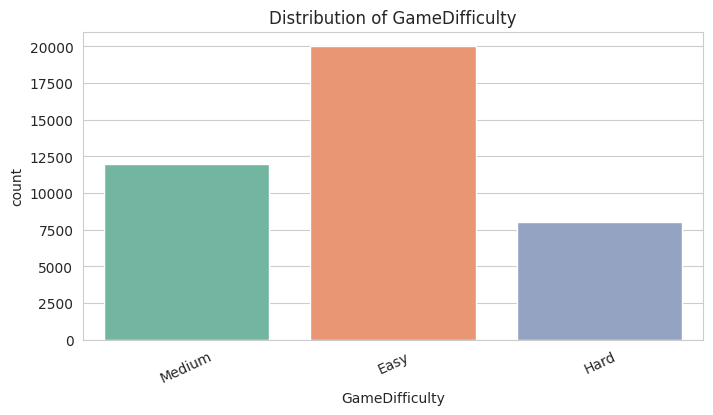

In [14]:
# Display count plots for each categorical feature.
cat_features = df.select_dtypes(include='object').drop('EngagementLevel', axis=1).columns

for col in cat_features:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=25)
    plt.show()

# *09 - Data Preparation*

In [15]:
# Separate features (X) and target (y).
X = df.drop('EngagementLevel', axis=1)
y_raw = df['EngagementLevel'] 

# Encode target
engagement_order = ['Low', 'Medium', 'High']
ordinal_encoder = OrdinalEncoder(categories=[engagement_order])
y = ordinal_encoder.fit_transform(y_raw.values.reshape(-1, 1)).ravel()

In [16]:
X

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
0,9000,43,Male,Other,Strategy,16.271119,Medium,6,108,79,25
1,9001,29,Female,USA,Strategy,5.525961,Medium,5,144,11,10
2,9002,22,Female,USA,Sports,8.223755,Easy,16,142,35,41
3,9003,35,Male,USA,Action,5.265351,Easy,9,85,57,47
4,9004,33,Male,Europe,Action,15.531945,Medium,2,131,95,37
...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,Male,USA,Strategy,20.619662,Easy,4,75,85,14
40030,49030,44,Female,Other,Simulation,13.539280,Hard,19,114,71,27
40031,49031,15,Female,USA,RPG,0.240057,Easy,10,176,29,1
40032,49032,34,Male,USA,Sports,14.017818,Medium,3,128,70,10


In [17]:
y_raw

0        Medium
1        Medium
2          High
3        Medium
4        Medium
          ...  
40029    Medium
40030      High
40031      High
40032    Medium
40033    Medium
Name: EngagementLevel, Length: 40034, dtype: object

# ***9.1 - Convert Engagement into Binary Target***

In [18]:
# High = 1, Medium/Low = 0
y_binary = (y_raw == "High").astype(int)

# Split model
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, stratify=y_binary, random_state=42
)
print("Binary target created successfully (High vs Not High).")

Binary target created successfully (High vs Not High).


# *10 - Preprocessing Pipeline*

In [19]:
# Define transformation pipeline for numerical and categorical data.
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Apply scaling to numeric features and one-hot encoding to categorical features.
numeric_transformer = Pipeline([('scaler', StandardScaler())])
categorical_transformer = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [20]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ***11 - Train Models (Main)***

Training and evaluating the models...

Logistic Regression
Accuracy: 0.7928
Precision (weighted): 0.8034
Recall (weighted): 0.7928
F1-score (weighted): 0.7927
----------------------------------------
Decision Tree
Accuracy: 0.8257
Precision (weighted): 0.8255
Recall (weighted): 0.8257
F1-score (weighted): 0.8256
----------------------------------------
Random Forest
Accuracy: 0.9078
Precision (weighted): 0.9084
Recall (weighted): 0.9078
F1-score (weighted): 0.9075
----------------------------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002752 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 917
[LightGBM] [Info] Number of data points in the train set: 32027, number of used features: 21
[LightGBM] [Info] Start training from score -1.355276
[LightGBM] [Info] Start training from score -0.725804
[LightGBM] [Info] Start traini

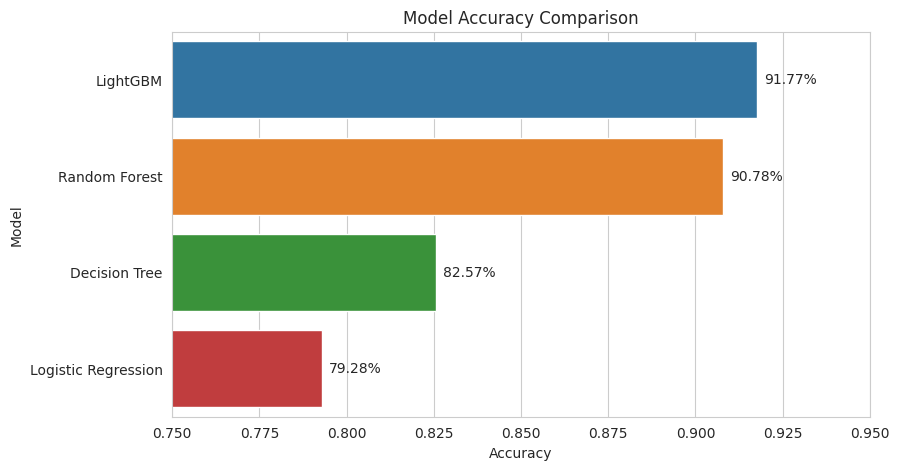

In [21]:
from tqdm import tqdm
# Trying out a few different models to compare their accuracy
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=200, random_state=42),
    "LightGBM": LGBMClassifier(is_unbalance=True, random_state=42)
}

model_results = []
all_reports = {}

print("Training and evaluating the models...\n")

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    report = classification_report(y_test, preds, target_names=engagement_order, output_dict=True)
    accuracy = report["accuracy"]

    model_results.append([name, accuracy])
    all_reports[name] = {
        "preds": preds,
        "report": report,
        "pipeline": pipeline
    }

    print(f"{name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (weighted): {report['weighted avg']['precision']:.4f}")
    print(f"Recall (weighted): {report['weighted avg']['recall']:.4f}")
    print(f"F1-score (weighted): {report['weighted avg']['f1-score']:.4f}")
    print("-" * 40)

# Plotting the model comparison
results_df = pd.DataFrame(model_results, columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x="Accuracy", y="Model")
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

for i, v in enumerate(results_df["Accuracy"]):
    plt.text(v + 0.002, i, f"{v*100:.2f}%", va="center")

plt.xlim(0.75, 0.95)
plt.show()


# *11.1 - Train Binary Classification Model (Random Forest)*


===== BINARY CLASSIFICATION REPORT (High vs Not High) =====
              precision    recall  f1-score   support

    Not High       0.95      0.97      0.96      5940
        High       0.92      0.87      0.89      2067

    accuracy                           0.95      8007
   macro avg       0.94      0.92      0.93      8007
weighted avg       0.94      0.95      0.94      8007



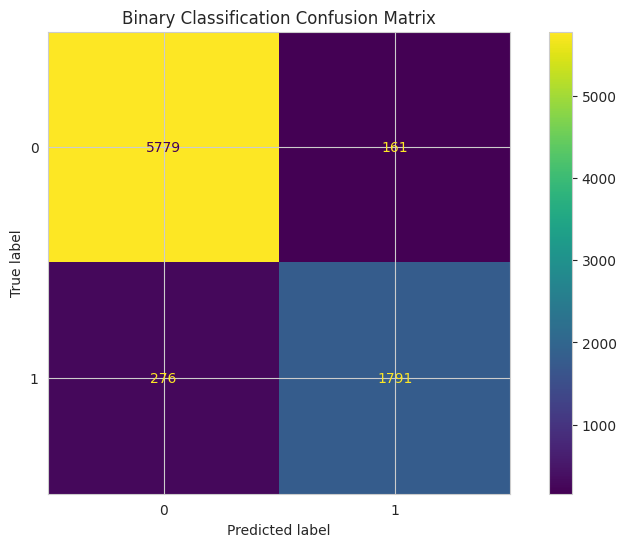

In [22]:
binary_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42))
])

binary_model.fit(X_train_bin, y_train_bin)
y_pred_bin = binary_model.predict(X_test_bin)

print("\n===== BINARY CLASSIFICATION REPORT (High vs Not High) =====")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Not High', 'High']))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test_bin, y_pred_bin)
plt.title("Binary Classification Confusion Matrix")
plt.show()

# *12 - Model Comparison (Bar Chart)*

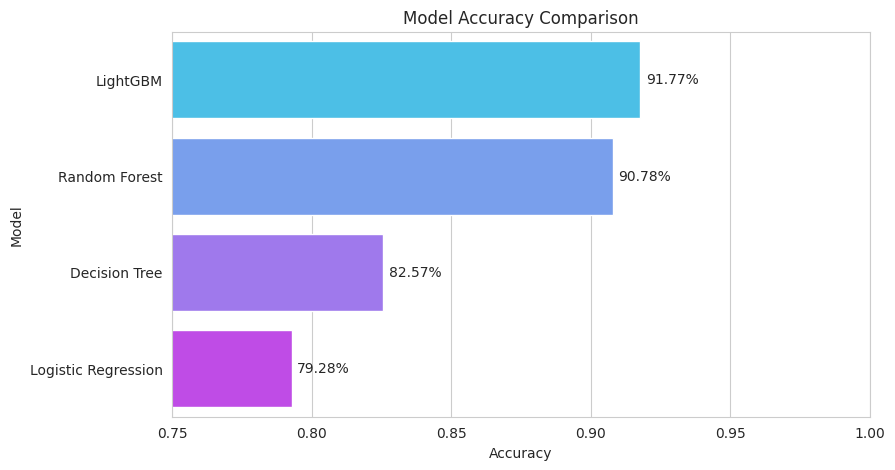

In [23]:
# Plot a bar chart of model accuracies.
results_df = pd.DataFrame(model_results, columns=['Model', 'Accuracy']).sort_values('Accuracy', ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x='Accuracy', y='Model', palette='cool')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')

# Annotate accuracy percentages
for i, v in enumerate(results_df['Accuracy']):
    plt.text(v + 0.002, i, f"{v*100:.2f}%", va='center')

plt.xlim(0.75, 1)
plt.show()


# *12.1 - ROC Curve for Binary Model*

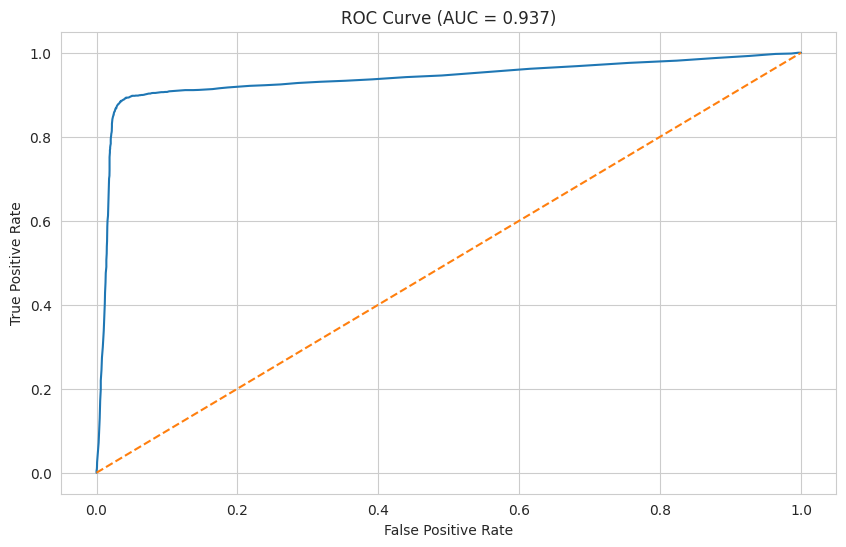

In [24]:
y_prob_bin = binary_model.predict_proba(X_test_bin)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_bin, y_prob_bin)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title(f'ROC Curve (AUC = {roc_auc:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

# *13 - Confusion Matrix (Best Model: Random Forest)*

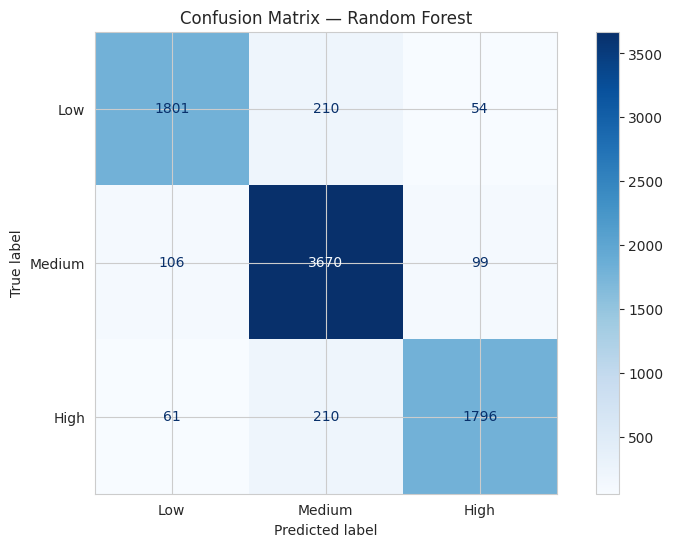

In [25]:
# Display confusion matrix for the best-performing model (Random Forest).
best_model = all_reports['Random Forest']['pipeline']

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, display_labels=engagement_order, cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.show()

# *14 - Feature Importance*

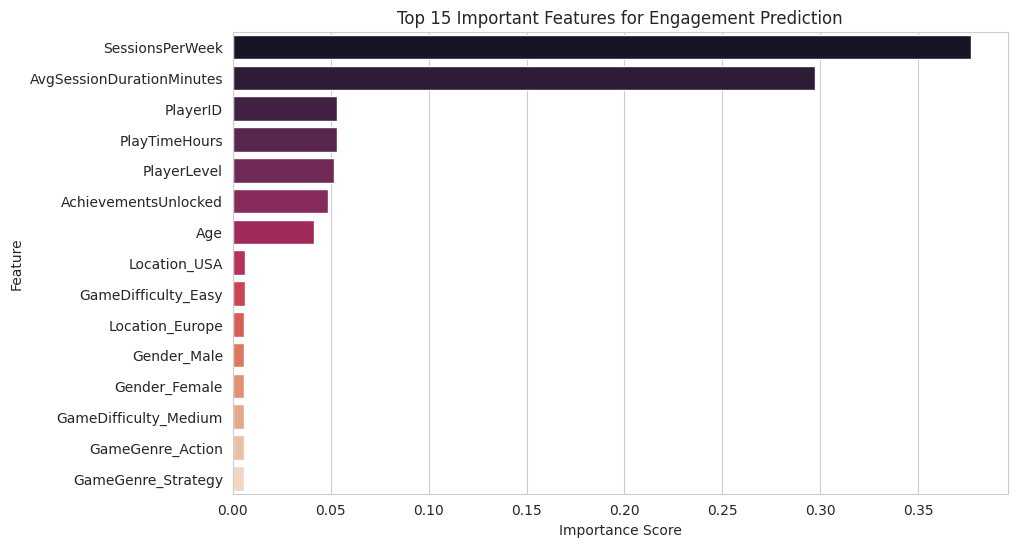

In [26]:
# Extract and plot feature importance scores from Random Forest.
preproc = best_model.named_steps['preprocessor']
model = best_model.named_steps['model']

ohe_names = preproc.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_features = numeric_features + ohe_names.tolist()
# Identify which features most influence player engagement.
importances = pd.Series(model.feature_importances_, index=all_features).sort_values(ascending=False)[:15]

sns.barplot(x=importances.values, y=importances.index, palette='rocket')
plt.title('Top 15 Important Features for Engagement Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# *15 - Multi-Class ROC Curve*

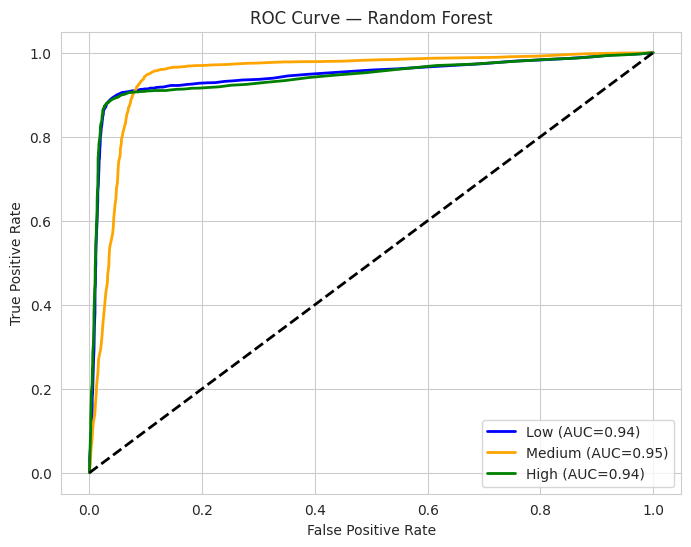

In [27]:
# Plot ROC curve for each engagement class.
y_prob = best_model.predict_proba(X_test)
y_bin = label_binarize(y_test, classes=[0,1,2])
n_classes = len(engagement_order)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
colors = ['blue', 'orange', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{engagement_order[i]} (AUC={roc_auc[i]:.2f})')
plt.plot([0,1],[0,1],'k--',lw=2)
plt.title('ROC Curve — Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [28]:
# Check all columns in your dataset
print(df.columns.tolist())

['PlayerID', 'Age', 'Gender', 'Location', 'GameGenre', 'PlayTimeHours', 'GameDifficulty', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'EngagementLevel']


# *16 - Boxplot for PlayTime vs Engagement Level*

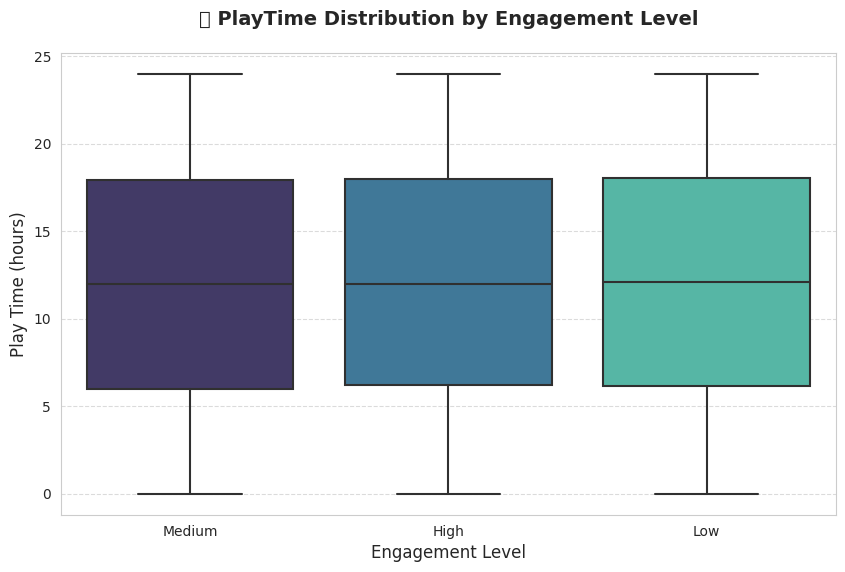

In [29]:

# --- Auto detect correct column name ---
play_col = None
for col in df.columns:
    if "play" in col.lower() and "time" in col.lower():
        play_col = col
        break

if play_col is None:
    raise ValueError("No column found related to 'PlayTime' in dataset.")

# --- Create the visualization ---
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, 
    x="EngagementLevel", 
    y=play_col, 
    palette="mako", 
    linewidth=1.5, 
    saturation=0.8
)

# --- Title and Aesthetic Enhancements ---
plt.title("🎮 PlayTime Distribution by Engagement Level", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Engagement Level", fontsize=12)
plt.ylabel("Play Time (hours)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# *17 - Final Model Accuracy*

In [30]:
# Final: Print model accuracies only
print("\nFinal Model Accuracies (using model_results):")
for name, acc in model_results:
    print(f"{name}: {acc:.4f}")


Final Model Accuracies (using model_results):
Logistic Regression: 0.7928
Decision Tree: 0.8257
Random Forest: 0.9078
LightGBM: 0.9177


#                                **---x--x--THE END--X--X---**